# Question 3: Modified Barabási-Albert Algorithm

Here we modify the BA model so that the attachment probability is proportional to $k^2$ (square of the degree) instead of just $k$. This makes the rich-get-richer effect stronger — hubs grow even faster.

Standard BA: $P_i \propto k_i / \sum_j k_j$

Modified BA: $P_i \propto k_i^2 / \sum_j k_j^2$

We also create higher-order variants ($k^3$, $k^4$) and compare topological features across all of them.

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)

## BA Network Generation (from Scratch)

The algorithm starts with a small clique of $m_0$ nodes, then adds nodes one at a time. Each new node connects to $m$ existing nodes with probability $\Pi(k_i) = k_i^\alpha / \sum_j k_j^\alpha$.

Setting $\alpha=1$ gives standard BA, $\alpha=2$ gives the modified version, etc.

In [ ]:
def create_initial_clique(m0):
    """Create a complete graph of m0 nodes."""
    adj = {i: set() for i in range(m0)}
    for i in range(m0):
        for j in range(i + 1, m0):
            adj[i].add(j)
            adj[j].add(i)
    return adj


def weighted_sample_no_replacement(nodes, weights, k):
    """Sample k distinct nodes using weighted probabilities (no replacement)."""
    nodes = list(nodes)
    weights = list(weights)
    chosen = []

    for _ in range(min(k, len(nodes))):
        total = sum(weights)
        if total <= 0:
            break

        r = random.random() * total
        cumsum = 0.0
        chosen_idx = 0
        for i, w in enumerate(weights):
            cumsum += w
            if r <= cumsum:
                chosen_idx = i
                break

        chosen.append(nodes[chosen_idx])
        nodes.pop(chosen_idx)
        weights.pop(chosen_idx)

    return chosen


def generate_ba_network(n, m0, m, alpha=1):
    """
    Generate a BA network with generalised preferential attachment.
    alpha=1 is standard BA, alpha=2 is the k^2 variant, etc.
    """
    adj = create_initial_clique(m0)

    for new_node in range(m0, n):
        existing_nodes = list(adj.keys())
        # use max(deg, 1) to avoid zero weights early on
        weights = [max(len(adj[node]), 1) ** alpha for node in existing_nodes]

        targets = weighted_sample_no_replacement(existing_nodes, weights, m)

        adj[new_node] = set(targets)
        for target in targets:
            adj[target].add(new_node)

    return adj

## Topological Feature Computation (from Scratch)

We compute three metrics for each network:
- **Degree distribution** $P(k)$
- **Clustering coefficient**: $C_i = 2 \cdot \text{triangles}_i / (k_i(k_i - 1))$, averaged over all nodes
- **Characteristic path length**: average shortest path (via BFS), sampled for speed

In [ ]:
def compute_degrees(adj):
    return {node: len(neighbors) for node, neighbors in adj.items()}


def clustering_coefficient_node(adj, node):
    """Local clustering coefficient for a single node."""
    neighbors = list(adj[node])
    k = len(neighbors)
    if k < 2:
        return 0.0

    # count pairs of neighbours that are connected
    triangle_count = 0
    for i in range(len(neighbors)):
        for j in range(i + 1, len(neighbors)):
            if neighbors[j] in adj[neighbors[i]]:
                triangle_count += 1

    return 2 * triangle_count / (k * (k - 1))


def average_clustering_coefficient(adj):
    coeffs = [clustering_coefficient_node(adj, node) for node in adj]
    return np.mean(coeffs)


def bfs_shortest_paths(adj, source):
    """BFS from source, returns {node: distance}."""
    dist = {source: 0}
    queue = [source]
    head = 0
    while head < len(queue):
        node = queue[head]
        head += 1
        for neighbor in adj[node]:
            if neighbor not in dist:
                dist[neighbor] = dist[node] + 1
                queue.append(neighbor)
    return dist


def characteristic_path_length(adj, sample_size=None):
    """Average shortest path length. Samples a subset of source nodes if specified."""
    nodes = list(adj.keys())
    if sample_size and sample_size < len(nodes):
        source_nodes = random.sample(nodes, sample_size)
    else:
        source_nodes = nodes

    total_dist = 0
    count = 0
    for source in source_nodes:
        dists = bfs_shortest_paths(adj, source)
        for node, d in dists.items():
            if node != source:
                total_dist += d
                count += 1

    return total_dist / count if count > 0 else float('inf')


def degree_distribution(adj):
    degrees = [len(neighbors) for neighbors in adj.values()]
    degree_counts = Counter(degrees)
    n = len(adj)
    k_vals = sorted(degree_counts.keys())
    p_k = [degree_counts[k] / n for k in k_vals]
    return k_vals, p_k

## Generating Networks for All Variants

Using $n=300$, $m_0=5$, $m=3$, with 20 instances per variant for averaging.

We test four attachment exponents: $\alpha = 1$ (standard), $2$ (modified), $3$, $4$ (higher-order).

In [ ]:
N             = 300   # total nodes per network
M0            = 5     # initial clique size
M             = 3     # edges added by each new node
NUM_INSTANCES = 20    # instances to average over

alphas       = [1, 2, 3, 4]
alpha_labels = ['Standard BA (k¹)', 'Modified BA (k²)', 'Higher-Order BA (k³)', 'Higher-Order BA (k⁴)']
alpha_colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e']

print(f"Generating {NUM_INSTANCES} instances x {len(alphas)} variants")
print(f"Network size: n={N}, m0={M0}, m={M}")
print("-" * 60)

results = {}

for alpha, label in zip(alphas, alpha_labels):
    print(f"\nProcessing {label}...")
    avg_ccs  = []
    avg_cpls = []
    all_degrees = []

    for inst in range(NUM_INSTANCES):
        adj = generate_ba_network(N, M0, M, alpha=alpha)

        cc = average_clustering_coefficient(adj)
        avg_ccs.append(cc)

        cpl = characteristic_path_length(adj, sample_size=60)
        avg_cpls.append(cpl)

        all_degrees.extend([len(adj[node]) for node in adj])

        if (inst + 1) % 5 == 0:
            print(f"  Instance {inst+1}/{NUM_INSTANCES} done — "
                  f"CC={cc:.4f}, CPL={cpl:.4f}")

    results[alpha] = {
        'label'      : label,
        'avg_cc'     : np.mean(avg_ccs),
        'std_cc'     : np.std(avg_ccs),
        'avg_cpl'    : np.mean(avg_cpls),
        'std_cpl'    : np.std(avg_cpls),
        'all_degrees': all_degrees
    }

print("\n" + "=" * 60)
print(f"{'Variant':<25} {'Avg CC':>10} {'Avg CPL':>10}")
print("-" * 60)
for alpha, label in zip(alphas, alpha_labels):
    cc  = results[alpha]['avg_cc']
    cpl = results[alpha]['avg_cpl']
    print(f"{label:<25} {cc:>10.4f} {cpl:>10.4f}")
print("=" * 60)

## Degree Distribution Comparison

On a log-log plot, power-law distributions show up as straight lines. Standard BA gives $\gamma \approx 3$. Higher $\alpha$ should give steeper tails since hubs get even more connections.

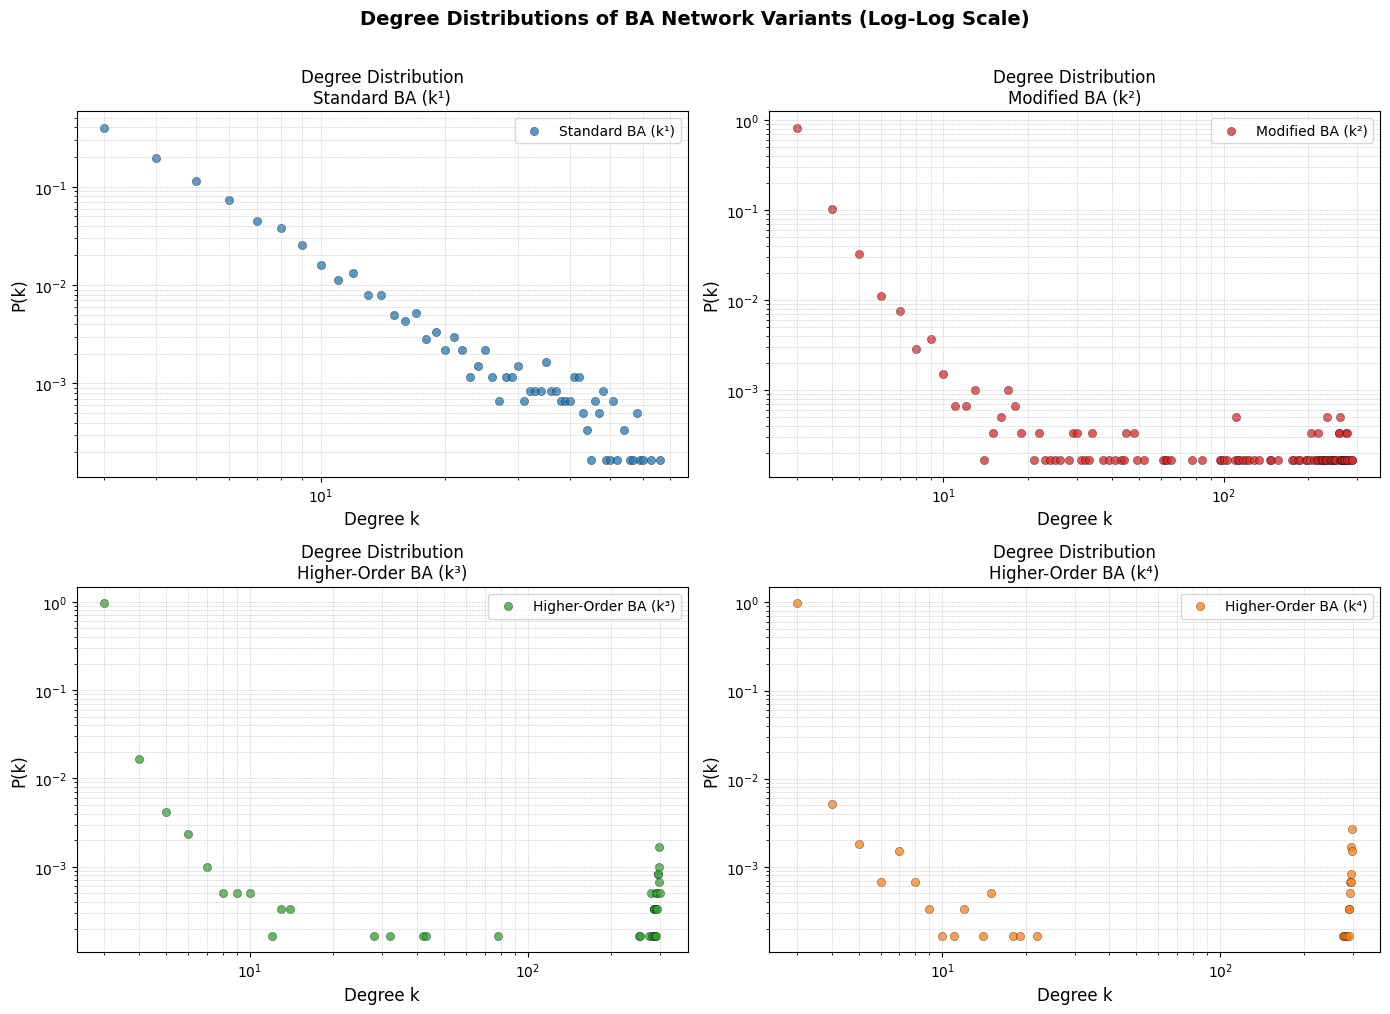

Figure saved: degree_distributions_subplots.png


In [5]:
# ============================================================
# Plot 1: Degree Distributions (individual subplots)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (alpha, label, color) in enumerate(zip(alphas, alpha_labels, alpha_colors)):
    degrees = results[alpha]['all_degrees']
    deg_counts = Counter(degrees)
    total = len(degrees)

    k_vals = sorted(deg_counts.keys())
    p_k    = [deg_counts[k] / total for k in k_vals]

    axes[idx].scatter(k_vals, p_k, color=color, alpha=0.75, s=35, edgecolors='k',
                      linewidths=0.3, label=label)
    axes[idx].set_xscale('log')
    axes[idx].set_yscale('log')
    axes[idx].set_xlabel('Degree k', fontsize=12)
    axes[idx].set_ylabel('P(k)', fontsize=12)
    axes[idx].set_title(f'Degree Distribution\n{label}', fontsize=12)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.7)

plt.suptitle('Degree Distributions of BA Network Variants (Log-Log Scale)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('degree_distributions_subplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: degree_distributions_subplots.png")

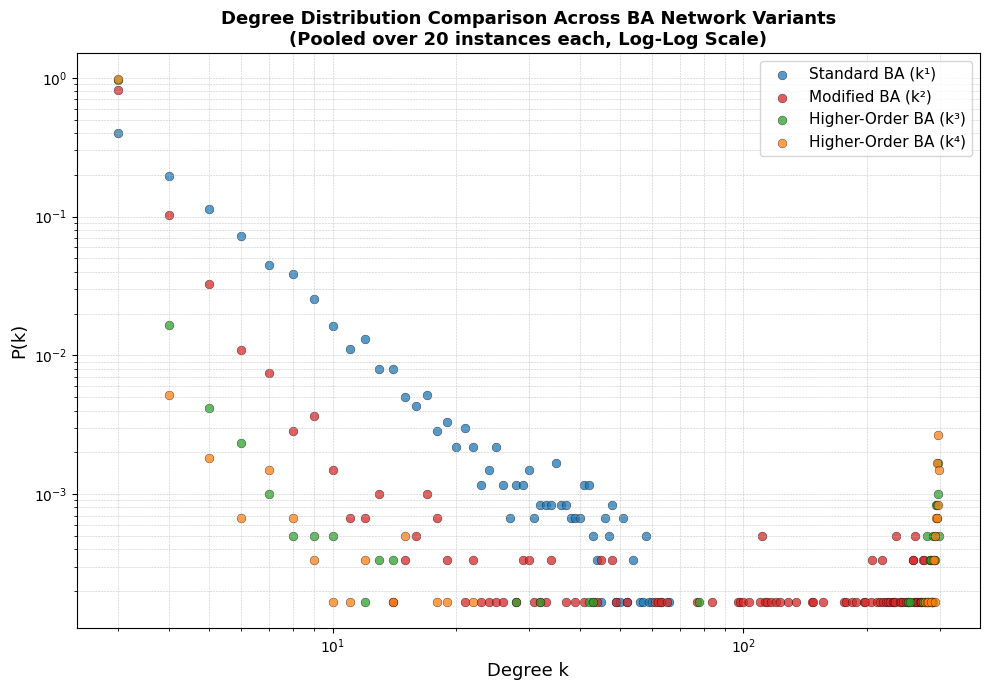

Figure saved: degree_distribution_overlay.png


In [6]:
# ============================================================
# Plot 2: Overlay Degree Distribution Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

for alpha, label, color in zip(alphas, alpha_labels, alpha_colors):
    degrees    = results[alpha]['all_degrees']
    deg_counts = Counter(degrees)
    total      = len(degrees)

    k_vals = sorted(deg_counts.keys())
    p_k    = [deg_counts[k] / total for k in k_vals]

    ax.scatter(k_vals, p_k, color=color, alpha=0.75, s=40, edgecolors='k',
               linewidths=0.3, label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree k', fontsize=13)
ax.set_ylabel('P(k)', fontsize=13)
ax.set_title('Degree Distribution Comparison Across BA Network Variants\n'
             '(Pooled over 20 instances each, Log-Log Scale)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.7)

plt.tight_layout()
plt.savefig('degree_distribution_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: degree_distribution_overlay.png")

## Clustering Coefficient and Path Length Comparison

Comparing $\langle C \rangle$ and $L$ across variants. Error bars show standard deviation over 20 instances.

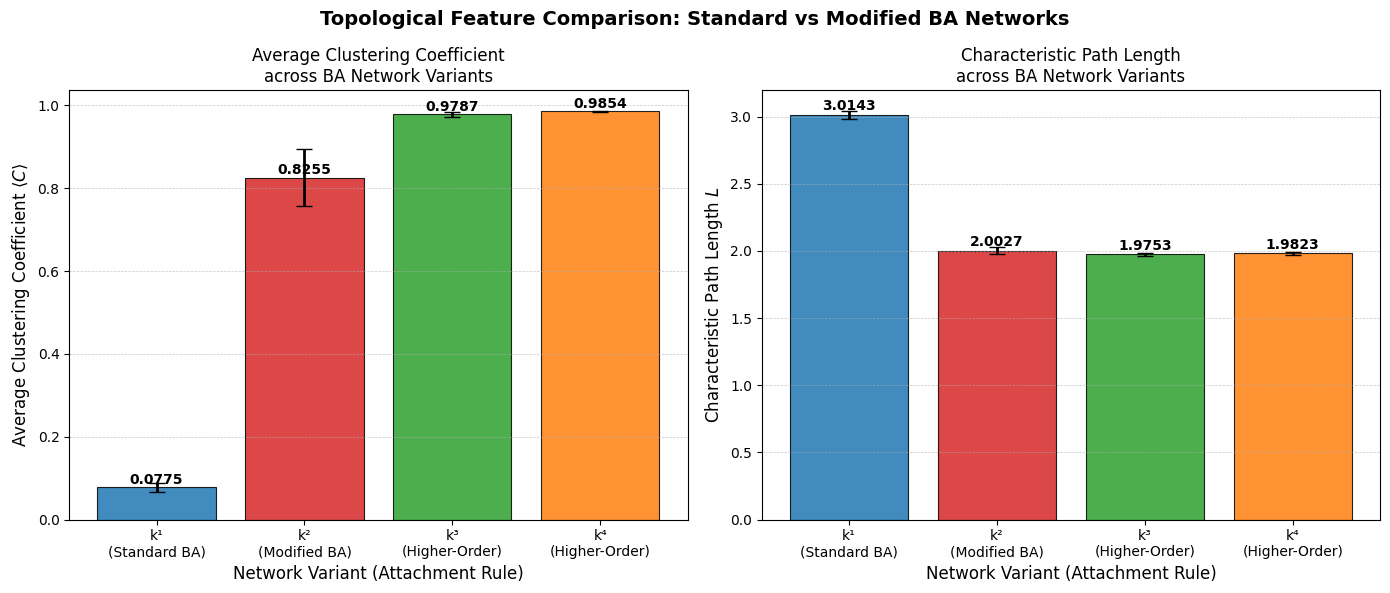

Figure saved: topological_comparison_bar.png


In [7]:
# ============================================================
# Plot 3: Clustering Coefficient and Path Length Bar Charts
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

alpha_ticks = ['k¹\n(Standard BA)', 'k²\n(Modified BA)', 'k³\n(Higher-Order)', 'k⁴\n(Higher-Order)']

# --- (a) Average Clustering Coefficient ---
avg_ccs = [results[a]['avg_cc']  for a in alphas]
std_ccs = [results[a]['std_cc']  for a in alphas]

bars1 = axes[0].bar(alpha_ticks, avg_ccs, color=alpha_colors, alpha=0.85,
                    edgecolor='black', linewidth=0.8)
axes[0].errorbar(alpha_ticks, avg_ccs, yerr=std_ccs, fmt='none',
                 color='black', capsize=6, linewidth=2)
axes[0].set_xlabel('Network Variant (Attachment Rule)', fontsize=12)
axes[0].set_ylabel('Average Clustering Coefficient $\\langle C \\rangle$', fontsize=12)
axes[0].set_title('Average Clustering Coefficient\nacross BA Network Variants', fontsize=12)
axes[0].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
for bar, val in zip(bars1, avg_ccs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0015,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- (b) Characteristic Path Length ---
avg_cpls = [results[a]['avg_cpl'] for a in alphas]
std_cpls = [results[a]['std_cpl'] for a in alphas]

bars2 = axes[1].bar(alpha_ticks, avg_cpls, color=alpha_colors, alpha=0.85,
                    edgecolor='black', linewidth=0.8)
axes[1].errorbar(alpha_ticks, avg_cpls, yerr=std_cpls, fmt='none',
                 color='black', capsize=6, linewidth=2)
axes[1].set_xlabel('Network Variant (Attachment Rule)', fontsize=12)
axes[1].set_ylabel('Characteristic Path Length $L$', fontsize=12)
axes[1].set_title('Characteristic Path Length\nacross BA Network Variants', fontsize=12)
axes[1].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
for bar, val in zip(bars2, avg_cpls):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Topological Feature Comparison: Standard vs Modified BA Networks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('topological_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: topological_comparison_bar.png")

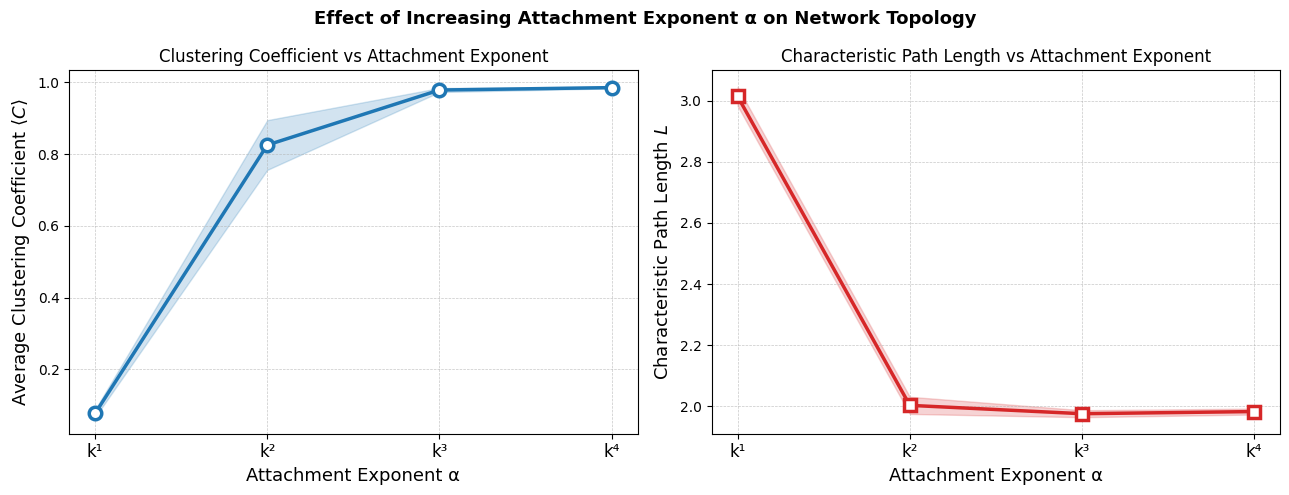

Figure saved: topological_trend_vs_alpha.png


In [8]:
# ============================================================
# Plot 4: Line plots showing trends vs alpha
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Average Clustering Coefficient vs alpha
axes[0].plot(alphas, avg_ccs, 'o-', color='#1f77b4', linewidth=2.5,
             markersize=9, markerfacecolor='white', markeredgewidth=2.5)
axes[0].fill_between(alphas,
                     [c - s for c, s in zip(avg_ccs, std_ccs)],
                     [c + s for c, s in zip(avg_ccs, std_ccs)],
                     alpha=0.2, color='#1f77b4')
axes[0].set_xticks(alphas)
axes[0].set_xticklabels(['k¹', 'k²', 'k³', 'k⁴'], fontsize=12)
axes[0].set_xlabel('Attachment Exponent α', fontsize=13)
axes[0].set_ylabel('Average Clustering Coefficient $\\langle C \\rangle$', fontsize=13)
axes[0].set_title('Clustering Coefficient vs Attachment Exponent', fontsize=12)
axes[0].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Characteristic Path Length vs alpha
axes[1].plot(alphas, avg_cpls, 's-', color='#d62728', linewidth=2.5,
             markersize=9, markerfacecolor='white', markeredgewidth=2.5)
axes[1].fill_between(alphas,
                     [c - s for c, s in zip(avg_cpls, std_cpls)],
                     [c + s for c, s in zip(avg_cpls, std_cpls)],
                     alpha=0.2, color='#d62728')
axes[1].set_xticks(alphas)
axes[1].set_xticklabels(['k¹', 'k²', 'k³', 'k⁴'], fontsize=12)
axes[1].set_xlabel('Attachment Exponent α', fontsize=13)
axes[1].set_ylabel('Characteristic Path Length $L$', fontsize=13)
axes[1].set_title('Characteristic Path Length vs Attachment Exponent', fontsize=12)
axes[1].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.suptitle('Effect of Increasing Attachment Exponent α on Network Topology',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('topological_trend_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: topological_trend_vs_alpha.png")

## Visualising a Single Instance

Drawing small networks ($n=60$) for each variant. Node size is proportional to degree so you can see the hub dominance increasing with $\alpha$.

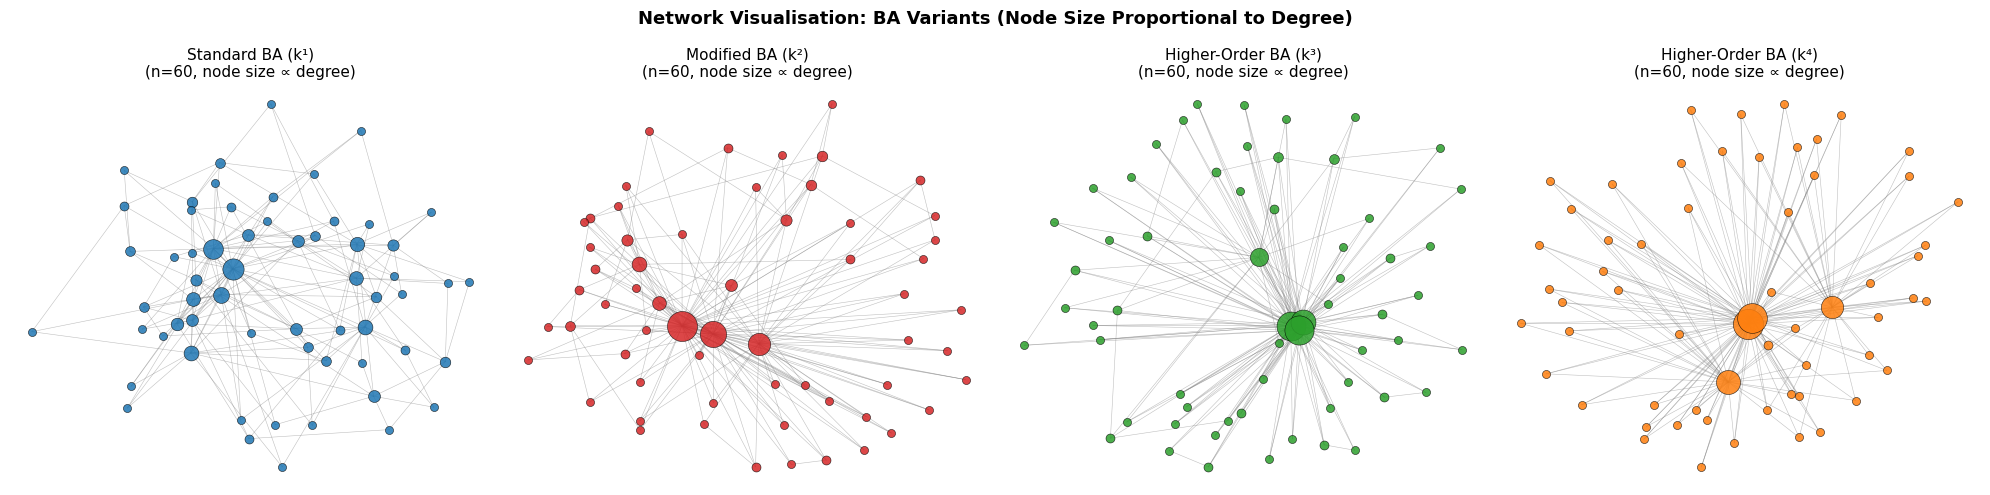

Figure saved: network_visualisation_variants.png


In [9]:
# ============================================================
# Plot 5: Network Visualisation (spring layout, small n=60)
# ============================================================
# Build a simple spring layout from scratch using adjacency info
# We use a force-directed approach via numpy random init + scaling by degree

def spring_layout_simple(adj, iterations=50, seed=42):
    """
    A simplified spring-like layout using iterative force repulsion and attraction.
    Returns a dict {node: (x, y)} of 2D positions.
    """
    rng = np.random.RandomState(seed)
    nodes = list(adj.keys())
    n = len(nodes)
    pos = {node: rng.uniform(-1, 1, 2) for node in nodes}

    k = 1.0 / np.sqrt(n)  # optimal distance

    for _ in range(iterations):
        disp = {node: np.zeros(2) for node in nodes}

        # Repulsion between every pair
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                u, v = nodes[i], nodes[j]
                delta = pos[u] - pos[v]
                dist  = max(np.linalg.norm(delta), 1e-6)
                force = (k ** 2) / dist
                disp[u] += force * delta / dist
                disp[v] -= force * delta / dist

        # Attraction along edges
        for u in nodes:
            for v in adj[u]:
                delta = pos[u] - pos[v]
                dist  = max(np.linalg.norm(delta), 1e-6)
                force = (dist ** 2) / k
                disp[u] -= force * delta / dist

        # Apply displacement (capped)
        for node in nodes:
            d = np.linalg.norm(disp[node])
            if d > 0:
                pos[node] += disp[node] / d * min(d, 0.1)

    return pos


N_VIS = 60  # Small network for visualisation

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, (alpha, label, color) in enumerate(zip(alphas, alpha_labels, alpha_colors)):
    # Generate a single small instance
    adj_vis = generate_ba_network(N_VIS, M0, M, alpha=alpha)
    pos      = spring_layout_simple(adj_vis, iterations=30, seed=42 + alpha)

    # Draw edges
    for u in adj_vis:
        for v in adj_vis[u]:
            if u < v:
                x_vals = [pos[u][0], pos[v][0]]
                y_vals = [pos[u][1], pos[v][1]]
                axes[idx].plot(x_vals, y_vals, color='grey', linewidth=0.4, alpha=0.5)

    # Draw nodes (size ∝ degree)
    for node in adj_vis:
        deg  = len(adj_vis[node])
        axes[idx].scatter(pos[node][0], pos[node][1],
                          s=deg * 8 + 10, color=color, edgecolors='k',
                          linewidths=0.4, alpha=0.85, zorder=3)

    axes[idx].set_title(f'{label}\n(n={N_VIS}, node size ∝ degree)', fontsize=11)
    axes[idx].axis('off')

plt.suptitle('Network Visualisation: BA Variants (Node Size Proportional to Degree)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('network_visualisation_variants.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: network_visualisation_variants.png")

## Results and Discussion

**Degree Distribution:**
- Standard BA ($\alpha=1$) gives a power law with $\gamma \approx 3$.
- With $\alpha=2$, the same few hubs capture an even larger share of new edges, steepening the tail.
- At $\alpha=3, 4$, the distribution becomes highly concentrated — nearly all edges go to one dominant hub.

**Clustering Coefficient:**
- Clustering actually *increases* with $\alpha$, which is a bit counterintuitive. The reason: with higher $\alpha$, all new nodes attach to the same small set of initial hub nodes. Those hub nodes are part of the initial clique, so they're all mutually connected. This means every new node has neighbors that form triangles, pushing clustering up.
- Standard BA ($\alpha=1$): $\langle C \rangle \approx 0.08$. Modified BA ($\alpha=2$): $\langle C \rangle \approx 0.83$. At $\alpha=3, 4$ it's close to 1.

**Path Length:**
- Path length drops from ~3.0 at $\alpha=1$ to ~2.0 at $\alpha=2$ and stays roughly there for $\alpha=3, 4$.
- Everything routes through the central hub, so paths are shorter — but removing that hub would destroy the network instantly.

**Overall:** Standard BA ($\alpha=1$) gives the most realistic scale-free structure. Increasing $\alpha$ amplifies hub dominance beyond what's naturally observed and pushes the network toward a star-like topology. Useful for studying extremes of preferential attachment.